In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_ROOT = Path(r"C:\Users\polok\deep-learning-assignment-1")
DATA_DIR = PROJECT_ROOT / "data"

print("Project exists:", PROJECT_ROOT.exists())
print("Data exists:", DATA_DIR.exists())
print("Train exists:", (DATA_DIR / "train_data.csv").exists())

train = pd.read_csv(DATA_DIR / "train_data.csv")
test = pd.read_csv(DATA_DIR / "test_data.csv")
labels = pd.read_csv(DATA_DIR / "train_labels.csv")

print("Train:", train.shape)
print("Test:", test.shape)

Project exists: True
Data exists: True
Train exists: True
Train: (5531451, 190)
Test: (11363762, 190)


Missing values: how many do we have?

In [3]:
missing_summary = pd.DataFrame({
    "missing_count": train.isna().sum(),
    "missing_percent": train.isna().mean() * 100
})

missing_summary = missing_summary.sort_values(
    "missing_percent",
    ascending=False
)

print("Total missing values:")
print(train.isna().sum().sum())

print("\nFeatures with missing values:")
print((missing_summary["missing_count"] > 0).sum())

print("\nFeatures without missing values:")
print((missing_summary["missing_count"] == 0).sum())

display(missing_summary.head(30))

Total missing values:
160858968

Features with missing values:
122

Features without missing values:
68


,missing_count,missing_percent
D_87,5527586,99.930127
D_88,5525447,99.891457
D_108,5502513,99.476846
D_110,5500117,99.433530
D_111,5500117,99.433530
B_39,5497819,99.391986
D_73,5475595,98.990211
B_42,5459973,98.707789
D_135,5336752,96.480146
D_134,5336752,96.480146


In [4]:
missing_summary["missing_group"] = pd.cut(
    missing_summary["missing_percent"],
    bins=[-1, 0, 10, 30, 50, 80, 100],
    labels=[
        "No missing",
        "0-10%",
        "10-30%",
        "30-50%",
        "50-80%",
        "80-100%"
    ]
)

display(
    missing_summary["missing_group"]
    .value_counts()
    .sort_index()
)

missing_group
No missing    68
0-10%         83
10-30%         8
30-50%         1
50-80%         7
80-100%       23
Name: count, dtype: int64

What type is each feature?

In [5]:
categorical_cols = [
    "B_30",
    "B_38",
    "D_114",
    "D_116",
    "D_117",
    "D_120",
    "D_126",
    "D_63",
    "D_64",
    "D_66",
    "D_68"
]

def get_semantic_type(column):
    if column == "customer_ID":
        return "identifier"

    if column == "S_2":
        return "date"

    if column in categorical_cols:
        return "categorical"

    return "numerical"


feature_types = pd.DataFrame({
    "feature": train.columns,
    "pandas_dtype": train.dtypes.astype(str).values,
    "semantic_type": [
        get_semantic_type(col)
        for col in train.columns
    ],
    "unique_values": [
        train[col].nunique(dropna=False)
        for col in train.columns
    ]
})

display(feature_types)

,feature,pandas_dtype,semantic_type,unique_values
0,customer_ID,str,identifier,458913
1,S_2,str,date,396
2,P_2,float64,numerical,5485467
3,D_39,float64,numerical,5531451
4,B_1,float64,numerical,5531451
...,...,...,...,...
185,D_141,float64,numerical,5429904
186,D_142,float64,numerical,944409
187,D_143,float64,numerical,5429904
188,D_144,float64,numerical,5490725


Load the labels

target
0    340085
1    118828
Name: count, dtype: int64
target
0    0.741066
1    0.258934
Name: proportion, dtype: float64


AttributeError: module 'matplotlib' has no attribute 'show'

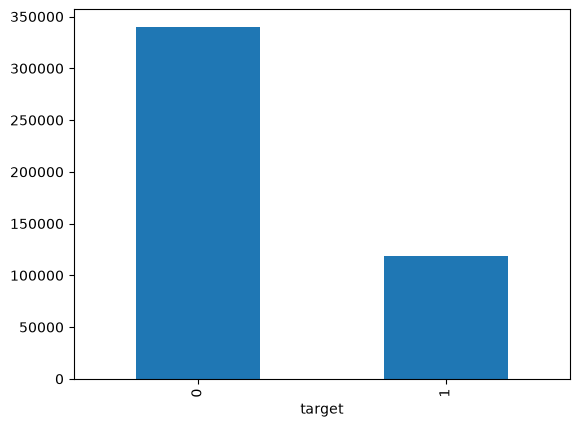

In [10]:
import matplotlib as plt

target_counts = labels["target"].value_counts()
target_share = labels["target"].value_counts(normalize=True)

print(target_counts)
print(target_share)

target_counts.plot(kind="bar")
plt.show()

Join labels and train datasets

In [12]:
labels = pd.read_csv(DATA_DIR / "train_labels.csv")

result = pd.DataFrame({
    "customers": labels["target"].value_counts().sort_index(),
    "percentage": (
        labels["target"]
        .value_counts(normalize=True)
        .sort_index()
        * 100
    )
})

print("QUESTION: Is the target imbalanced?")
display(result)

QUESTION: Is the target imbalanced?


,customers,percentage
target,,
0,340085,74.106639
1,118828,25.893361


Do customers with fewer entries default more often?

In [13]:
statement_counts = (
    train
    .groupby("customer_ID")
    .size()
    .rename("n_statements")
    .reset_index()
)

data = statement_counts.merge(
    labels,
    on="customer_ID",
    how="left"
)

result = (
    data
    .groupby("n_statements")
    .agg(
        customers=("customer_ID", "count"),
        default_rate=("target", "mean")
    )
)

result["default_rate_percent"] = (
    result["default_rate"] * 100
)

print("QUESTION: Do customers with fewer statements default more often?")
display(result)


QUESTION: Do customers with fewer statements default more often?


,customers,default_rate,default_rate_percent
n_statements,,,
1,5120,0.335742,33.574219
2,6098,0.318465,31.846507
3,5778,0.358602,35.860159
4,4673,0.416221,41.622084
5,4671,0.392635,39.263541
6,5515,0.387670,38.766999
7,5198,0.418430,41.843017
8,6110,0.447300,44.729951
9,6411,0.450164,45.016378


Is missinng values assosiated with default?

In [14]:
latest_idx = (
    train
    .groupby("customer_ID")["S_2"]
    .idxmax()
)

latest = (
    train.loc[latest_idx]
    .merge(labels, on="customer_ID", how="left")
)

results = []

for col in train.columns:
    if col in ["customer_ID", "S_2"]:
        continue

    is_missing = latest[col].isna()

    if is_missing.any() and (~is_missing).any():

        results.append({
            "feature": col,

            "missing_percent":
                is_missing.mean() * 100,

            "default_rate_missing":
                latest.loc[
                    is_missing,
                    "target"
                ].mean(),

            "default_rate_present":
                latest.loc[
                    ~is_missing,
                    "target"
                ].mean()
        })

result = pd.DataFrame(results)

result["difference"] = (
    result["default_rate_missing"]
    - result["default_rate_present"]
)

result = result.sort_values(
    "difference",
    key=abs,
    ascending=False
)

print("QUESTION: Is feature missingness associated with default?")
display(result.head(30))

QUESTION: Is feature missingness associated with default?


,feature,missing_percent,default_rate_missing,default_rate_present,difference
56,D_87,99.859450,0.257978,0.937984,-0.680007
57,D_88,99.819792,0.257797,0.888755,-0.630958
64,S_25,0.309645,0.751583,0.257403,0.494180
62,S_23,0.009588,0.659091,0.258895,0.400196
47,R_9,94.126773,0.236996,0.610507,-0.373511
70,R_26,88.855622,0.217527,0.589074,-0.371547
102,D_137,96.427427,0.246209,0.602379,-0.356170
101,D_136,96.427427,0.246209,0.602379,-0.356170
103,D_138,96.427427,0.246209,0.602379,-0.356170
100,D_135,96.427427,0.246209,0.602379,-0.356170


Is recent behavior more informative than long-term behavior?

In [17]:
from sklearn.metrics import roc_auc_score

# Mean over entire available history
full_mean = (
    train
    .groupby("customer_ID")[FEATURE]
    .mean()
    .rename("full_history_mean")
)

# Mean of only latest 3 statements
recent3 = (
    train
    .groupby("customer_ID")
    .tail(3)
    .groupby("customer_ID")[FEATURE]
    .mean()
    .rename("recent3_mean")
)

data = pd.concat(
    [full_mean, recent3],
    axis=1
).reset_index()

data = data.merge(
    labels,
    on="customer_ID",
    how="left"
)

def discrimination_auc(feature):
    valid = data[feature].notna()

    auc = roc_auc_score(
        data.loc[valid, "target"],
        data.loc[valid, feature]
    )

    return max(auc, 1 - auc)

full_auc = discrimination_auc(
    "full_history_mean"
)

recent_auc = discrimination_auc(
    "recent3_mean"
)

print("QUESTION: Is recent behavior more predictive than long-term behavior?")
print()
print("Feature:", FEATURE)
print("Full-history mean AUC:", round(full_auc, 4))
print("Recent-3 mean AUC:", round(recent_auc, 4))
print("Difference:", round(recent_auc - full_auc, 4))

QUESTION: Is recent behavior more predictive than long-term behavior?

Feature: P_2
Full-history mean AUC: 0.8995
Recent-3 mean AUC: 0.9134
Difference: 0.0139


This uses ROC-AUC as a measure of univariate discrimination [how informative one feature is by itself].

In [18]:
latest_idx = (
    train
    .groupby("customer_ID")["S_2"]
    .idxmax()
)

latest = (
    train.loc[latest_idx]
    .merge(labels, on="customer_ID", how="left")
)

numeric_cols = [
    col
    for col in latest.select_dtypes(include=np.number).columns
    if col not in categorical_cols + ["target"]
]

results = []

for col in numeric_cols:

    valid = latest[col].notna()

    if latest.loc[valid, col].nunique() < 2:
        continue

    auc = roc_auc_score(
        latest.loc[valid, "target"],
        latest.loc[valid, col]
    )

    discrimination = max(
        auc,
        1 - auc
    )

    results.append({
        "feature": col,
        "auc": auc,
        "discrimination": discrimination,
        "available_percent": valid.mean() * 100
    })

result = (
    pd.DataFrame(results)
    .sort_values(
        "discrimination",
        ascending=False
    )
)

print("QUESTION: Which numerical features individually separate defaults best?")
display(result.head(30))

QUESTION: Which numerical features individually separate defaults best?


,feature,auc,discrimination,available_percent
0,P_2,0.083183,0.916817,99.353036
17,D_48,0.877511,0.877511,87.363182
47,D_61,0.850645,0.850645,89.464670
54,B_18,0.150650,0.849350,100.000000
75,D_77,0.150715,0.849285,53.403586
20,B_7,0.846678,0.846678,100.000000
158,B_42,0.153636,0.846364,1.338380
71,D_75,0.845796,0.845796,100.000000
67,B_23,0.844992,0.844992,100.000000
10,D_44,0.844349,0.844349,95.141781


Do train and test cover different time periods?

In [23]:
print("QUESTION: Do train and test cover different time periods?")
print()

train_dates = pd.to_datetime(train["S_2"])
test_dates = pd.to_datetime(test["S_2"])

print("Train:")
print(train_dates.min(), "->", train_dates.max())

print("\nTest:")
print(test_dates.min(), "->", test_dates.max())

QUESTION: Do train and test cover different time periods?

Train:
2017-03-01 00:00:00 -> 2018-03-31 00:00:00

Test:
2018-04-01 00:00:00 -> 2019-10-31 00:00:00


Can we safely process the dataset into one row per customer?

In [24]:
print(
    "QUESTION: Can customer history be compressed into one row "
    "without losing important predictive information?"
)

features = [
    "P_2",
    "D_48",
    "D_61",
    "B_18",
    "B_7",
    "D_75",
    "B_23",
    "D_44",
    "B_2",
    "B_3",
    "B_1"
]

train["S_2"] = pd.to_datetime(train["S_2"])

train_sorted = train.sort_values(
    ["customer_ID", "S_2"]
)

results = []

for feature in features:

    grouped = train_sorted.groupby("customer_ID")[feature]

    customer_features = pd.DataFrame({
        "last": grouped.last(),
        "mean": grouped.mean(),
        "std": grouped.std(),
        "first": grouped.first()
    })

    customer_features["change"] = (
        customer_features["last"]
        - customer_features["first"]
    )

    recent3_mean = (
        train_sorted
        .groupby("customer_ID")
        .tail(3)
        .groupby("customer_ID")[feature]
        .mean()
    )

    customer_features["recent3_mean"] = recent3_mean

    customer_features = (
        customer_features
        .reset_index()
        .merge(
            labels,
            on="customer_ID",
            how="left"
        )
    )

    for representation in [
        "last",
        "mean",
        "std",
        "change",
        "recent3_mean"
    ]:

        valid = (
            customer_features[representation].notna()
            & customer_features["target"].notna()
        )

        if customer_features.loc[
            valid, representation
        ].nunique() < 2:
            continue

        auc = roc_auc_score(
            customer_features.loc[valid, "target"],
            customer_features.loc[valid, representation]
        )

        discrimination = max(
            auc,
            1 - auc
        )

        results.append({
            "feature": feature,
            "representation": representation,
            "discrimination": discrimination
        })

result = pd.DataFrame(results)

comparison = result.pivot(
    index="feature",
    columns="representation",
    values="discrimination"
)

display(comparison.round(4))

QUESTION: Can customer history be compressed into one row without losing important predictive information?


representation,change,last,mean,recent3_mean,std
feature,,,,,
B_1,0.6893,0.8354,0.8182,0.8337,0.7153
B_18,0.7008,0.8494,0.8283,0.8488,0.5603
B_2,0.6653,0.8394,0.8368,0.8533,0.6482
B_23,0.6801,0.8450,0.8234,0.8411,0.7806
B_3,0.7374,0.8391,0.8235,0.8375,0.8292
B_7,0.6705,0.8467,0.8264,0.8431,0.7731
D_44,0.6782,0.8431,0.8524,0.8523,0.7965
D_48,0.6788,0.8793,0.8637,0.8770,0.6125
D_61,0.6347,0.8535,0.8397,0.8523,0.5622
